
# Agente de IA en Google Colab  
## Random Forest (Iris) + Qwen 1.5–7B para interpretación de resultados

Este notebook construye un **agente de IA** que combina:

1. Un modelo de *Machine Learning* clásico (`RandomForestClassifier`) sobre el dataset Iris.
2. Un modelo de lenguaje grande (**Qwen 1.5–7B Chat**) que:
   - Lee las métricas del modelo de ML.
   - Genera un **reporte ejecutivo** en español.
   - Produce **conclusiones detalladas y recomendaciones técnicas y estratégicas**.

> ⚠️ Requiere ejecutar en **Google Colab con GPU activada**.


## 1. Instalación de dependencias

In [6]:
!pip install -q transformers accelerate sentencepiece torch scikit-learn matplotlib

## 2. Importación de librerías

In [7]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 3. Definición del agente de IA `MLReportingAgentQwen`

In [8]:

class MLReportingAgentQwen:

    def __init__(self,
                 test_size: float = 0.2,
                 random_state: int = 42,
                 llm_model_name: str = "Qwen/Qwen1.5-7B-Chat"):
        # Parámetros de ML
        self.test_size = test_size
        self.random_state = random_state

        # Parámetros del LLM
        self.llm_model_name = llm_model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        # Placeholders de datos y modelo
        self.X_train = None
        self.X_test  = None
        self.y_train = None
        self.y_test  = None
        self.target_names = None

        self.rf_model = None
        self.metrics = {}

        # LLM
        self.tokenizer = None
        self.llm = None

    # 1) Carga y partición del dataset
    def load_data(self):
        iris = load_iris()
        X = iris.data
        y = iris.target
        self.target_names = iris.target_names

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            stratify=y,
            random_state=self.random_state
        )

        print("✅ Datos Iris cargados y divididos en train/test.")
        print(f"  - Train: {self.X_train.shape[0]} muestras")
        print(f"  - Test : {self.X_test.shape[0]} muestras")

    # 2) Entrenamiento del Random Forest
    def train_model(self,
                    n_estimators: int = 200,
                    max_depth: int = None):
        self.rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=self.random_state
        )
        self.rf_model.fit(self.X_train, self.y_train)
        print("✅ Modelo Random Forest entrenado correctamente.")

    # 3) Evaluación y métricas
    def evaluate_model(self):
        y_pred = self.rf_model.predict(self.X_test)

        acc = accuracy_score(self.y_test, y_pred)
        report = classification_report(
            self.y_test, y_pred,
            target_names=self.target_names,
            output_dict=True
        )
        cm = confusion_matrix(self.y_test, y_pred)

        self.metrics = {
            "accuracy": acc,
            "classification_report": report,
            "confusion_matrix": cm
        }

        print(f"✅ Evaluación completada. Accuracy: {acc:.4f}")
        return self.metrics

    # 4) Visualización: matriz de confusión
    def plot_confusion_matrix(self):
        cm = self.metrics["confusion_matrix"]
        fig, ax = plt.subplots()

        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(self.target_names)))
        ax.set_yticks(range(len(self.target_names)))
        ax.set_xticklabels(self.target_names)
        ax.set_yticklabels(self.target_names)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j],
                        ha="center", va="center")

        plt.title("Matriz de confusión - Random Forest (Iris)")
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.colorbar(im)
        plt.show()

    # 5) Carga del modelo de lenguaje Qwen
    def load_llm(self):
        print(f"⏳ Cargando modelo de lenguaje: {self.llm_model_name} ...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.llm_model_name)
        self.llm = AutoModelForCausalLM.from_pretrained(
            self.llm_model_name,
            dtype=torch.float16,
            device_map="auto"
        )
        print("✅ Modelo de lenguaje Qwen cargado y listo.")

    # 6) Construcción del prompt para reporte ejecutivo
    def build_executive_prompt(self) -> str:
        acc = self.metrics["accuracy"]
        report = self.metrics["classification_report"]

        lineas_clases = []
        for clase in self.target_names:
            stats = report[clase]
            lineas_clases.append(
                f"- {clase}: precision={stats['precision']:.3f}, recall={stats['recall']:.3f}, f1={stats['f1-score']:.3f}"
            )
        metricas_por_clase = "\n".join(lineas_clases)

        prompt = f"""
Responde únicamente en español.

Eres un científico de datos senior y debes redactar un **reporte ejecutivo**.

Tienes las métricas de un modelo de clasificación Random Forest entrenado sobre el dataset Iris:

- Exactitud global (accuracy): {acc:.3f}

Métricas por clase:
{metricas_por_clase}

Con esta información, redacta un reporte ejecutivo para un directivo no técnico que incluya:
1. Una evaluación clara del desempeño global del modelo.
2. Una explicación del comportamiento por clase.
3. Un comentario sobre si el modelo es adecuado para uso en producción en este contexto.
4. Riesgos o limitaciones principales que deberían considerarse.

Condiciones de forma:
- Escribe de 2 a 4 párrafos.
- Solo en español.
- Tono formal, claro y conciso.
- No utilices listas; redacta en texto corrido.
"""
        return prompt.strip()

    # 7) Construcción del prompt para conclusiones detalladas
    def build_conclusions_prompt(self) -> str:
        acc = self.metrics["accuracy"]
        report = self.metrics["classification_report"]

        lineas_clases = []
        for clase in self.target_names:
            stats = report[clase]
            lineas_clases.append(
                f"- {clase}: precision={stats['precision']:.3f}, recall={stats['recall']:.3f}, f1={stats['f1-score']:.3f}"
            )
        metricas_por_clase = "\n".join(lineas_clases)

        prompt = f"""
Responde únicamente en español.

Eres un experto en aprendizaje automático y analítica avanzada, y debes redactar un análisis técnico.

Información disponible del modelo Random Forest sobre el dataset Iris:
- Exactitud global (accuracy): {acc:.3f}

Métricas por clase:
{metricas_por_clase}

Con esta información, genera un texto que incluya:

1. Un análisis profundo de las fortalezas y debilidades del modelo.
2. Identificación de posibles patrones de error o confusión entre clases y explicación plausible de por qué podrían ocurrir.
3. Recomendaciones técnicas específicas, incluyendo:
   - Ideas de ajuste de hiperparámetros.
   - Modelos alternativos a explorar.
   - Estrategias de validación y robustez.
4. Recomendaciones estratégicas para la organización:
   - Cómo y dónde usar este modelo.
   - Qué precauciones tomar.
   - Qué tipo de decisiones de negocio puede apoyar.
5. Una sección final de conclusiones, en tono ejecutivo, que sintetice el estado del modelo y próximos pasos.

Condiciones de forma:
- Responde solo en español.
- Redacta entre 4 y 7 párrafos extensos, sin listas ni viñetas.
- Emplea un tono formal y argumentativo.
- No repitas literalmente las instrucciones de este prompt.
"""
        return prompt.strip()

    # 8) Función auxiliar de generación
    def _generate_with_llm(self, prompt: str, max_new_tokens: int = 600) -> str:
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.llm.device)
        with torch.no_grad():
            output = self.llm.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=0.9,
                temperature=0.4
            )
        text = self.tokenizer.decode(output[0], skip_special_tokens=True)
        return text

    # 9) APIs públicas
    def generate_executive_report(self) -> str:
        prompt = self.build_executive_prompt()
        return self._generate_with_llm(prompt, max_new_tokens=400)

    def generate_detailed_conclusions(self) -> str:
        prompt = self.build_conclusions_prompt()
        return self._generate_with_llm(prompt, max_new_tokens=700)

    # 10) Pipeline completo
    def run_full_pipeline(self):
        print("▶️ Iniciando pipeline completo...")

        self.load_data()
        self.train_model()
        self.evaluate_model()
        self.plot_confusion_matrix()
        self.load_llm()

        executive_report = self.generate_executive_report()
        detailed_conclusions = self.generate_detailed_conclusions()

        print("✅ Textos generados por Qwen.")
        return executive_report, detailed_conclusions


## 4. Ejecutar el pipeline completo

▶️ Iniciando pipeline completo...
✅ Datos Iris cargados y divididos en train/test.
  - Train: 120 muestras
  - Test : 30 muestras
✅ Modelo Random Forest entrenado correctamente.
✅ Evaluación completada. Accuracy: 0.9000


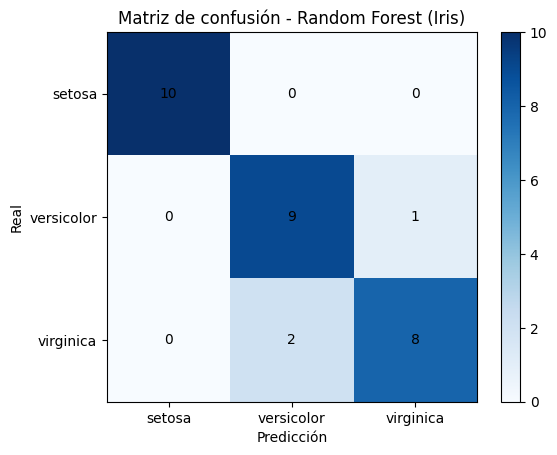

⏳ Cargando modelo de lenguaje: Qwen/Qwen1.5-7B-Chat ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:

agent = MLReportingAgentQwen(
    test_size=0.2,
    random_state=42,
    llm_model_name="Qwen/Qwen1.5-7B-Chat"
)

executive_report, detailed_conclusions = agent.run_full_pipeline()


## 5. Imprimir reporte ejecutivo y conclusiones detalladas

In [ ]:

from textwrap import fill

def print_block(title, text, width=100):
    print("\n" + "="*width)
    print(title)
    print("="*width + "\n")
    print(fill(text, width=width))
    print("\n")

print_block("📘 REPORTE EJECUTIVO (GENERADO POR QWEN)", executive_report)
print_block("📘 CONCLUSIONES DETALLADAS (GENERADAS POR QWEN)", detailed_conclusions)
